### Analisis pelanggan yang berpotensi *churn* (berhenti berbelanja) selama 3 bulan ke depan

#### IMPORT

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## 1. Data Preparation

In [2]:
df_kustomer = pd.read_csv('dataset_provinsi/customers.csv')
df_kustomer.head()

,customer_id,usia,jenis_kelamin,lama_berlangganan_bulan,total_transaksi,rata2_belanja,jumlah_komplain,status_churn
0,CUST0380,52.0,P,26.0,14.0,Rp 133.396,1.0,Tidak
1,CUST0129,18.0,L,28.0,13.0,Rp 212.717,1.0,Ya
2,CUST0281,28.0,P,2.0,26.0,Rp 212.831,3.0,Tidak
3,CUST0102,41.0,L,30.0,16.0,326424.0,0.0,Ya
4,CUST0354,35.0,P,14.0,14.0,Rp 355.193,0.0,Tidak


In [3]:
df_transaksi = pd.read_csv('dataset_provinsi/transaksi_tambahan.csv')
df_transaksi.head()

,customer_id,tanggal_transaksi_terakhir,jumlah_produk_dibeli,kategori_favorit
0,CUST0104,26-03-2024,2,Kosmetik
1,CUST0215,2024-06-28,12,Elektronik
2,CUST0111,2025-01-07,8,Rumah Tangga
3,CUST0177,2024-08-10,9,Elektronik
4,CUST0316,08-02-2024,12,Kosmetik


### 1.1 Penggabungan antara kedua csv tersebut menjadi satu

In [4]:
df_copy = pd.merge(df_transaksi, df_kustomer, on='customer_id', how='inner')
df_copy.head()

,customer_id,tanggal_transaksi_terakhir,jumlah_produk_dibeli,kategori_favorit,usia,jenis_kelamin,lama_berlangganan_bulan,total_transaksi,rata2_belanja,jumlah_komplain,status_churn
0,CUST0104,26-03-2024,2,Kosmetik,34.0,Perempuan,23.0,16.0,Rp 368.202,2.0,Ya
1,CUST0215,2024-06-28,12,Elektronik,19.0,P,22.0,18.0,259062.0,1.0,Tidak
2,CUST0111,2025-01-07,8,Rumah Tangga,56.0,laki-laki,52.0,253.0,Rp 371.076,0.0,Tidak
3,CUST0177,2024-08-10,9,Elektronik,42.0,M,29.0,12.0,168734.0,0.0,Ya
4,CUST0316,08-02-2024,12,Kosmetik,55.0,laki-laki,20.0,17.0,Rp 229.236,1.0,Ya


In [5]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 368 non-null    str    
 1   tanggal_transaksi_terakhir  368 non-null    str    
 2   jumlah_produk_dibeli        368 non-null    int64  
 3   kategori_favorit            368 non-null    str    
 4   usia                        356 non-null    float64
 5   jenis_kelamin               368 non-null    str    
 6   lama_berlangganan_bulan     368 non-null    float64
 7   total_transaksi             368 non-null    float64
 8   rata2_belanja               351 non-null    str    
 9   jumlah_komplain             353 non-null    float64
 10  status_churn                368 non-null    str    
dtypes: float64(4), int64(1), str(6)
memory usage: 31.8 KB


In [6]:
df_copy.isnull().sum()

customer_id                    0
tanggal_transaksi_terakhir     0
jumlah_produk_dibeli           0
kategori_favorit               0
usia                          12
jenis_kelamin                  0
lama_berlangganan_bulan        0
total_transaksi                0
rata2_belanja                 17
jumlah_komplain               15
status_churn                   0
dtype: int64

In [7]:
df_copy.duplicated().sum()

np.int64(8)

Insight :
- 6 tipe data str
- data kosong : 'usia': 12, 'rata2_belanja': 17, 'jumlah_komplain': 15
- data duplikat : 8 data duplikat

## 2. Data Preprocessing

### 2.1 Melakukan replace string

#### customer_id

In [8]:
print("Sebelum direplace :")
print(df_copy['customer_id'].head())

df_copy['customer_id'] = df_copy['customer_id'].str.replace('CUST', '', regex=False).astype(int)
df_copy['customer_id']

print("\nSetelah direplace")
print(df_copy['customer_id'].head())

Sebelum direplace :
0    CUST0104
1    CUST0215
2    CUST0111
3    CUST0177
4    CUST0316
Name: customer_id, dtype: str

Setelah direplace
0    104
1    215
2    111
3    177
4    316
Name: customer_id, dtype: int64


#### tanggal_transaksi_terakhir

In [9]:
print("Sebelum direplace :")
print(df_copy['tanggal_transaksi_terakhir'].head())

df_copy['tanggal_transaksi_terakhir'] = pd.to_datetime(
  df_copy['tanggal_transaksi_terakhir'], format='mixed', dayfirst=True, errors='coerce'
)

print("\nSetelah direplace :")
print(df_copy['tanggal_transaksi_terakhir'].head())

Sebelum direplace :
0    26-03-2024
1    2024-06-28
2    2025-01-07
3    2024-08-10
4    08-02-2024
Name: tanggal_transaksi_terakhir, dtype: str

Setelah direplace :
0   2024-03-26
1   2024-06-28
2   2025-07-01
3   2024-10-08
4   2024-02-08
Name: tanggal_transaksi_terakhir, dtype: datetime64[us]


In [10]:
df_copy['tanggal_transaksi_terakhir'].head()

0   2024-03-26
1   2024-06-28
2   2025-07-01
3   2024-10-08
4   2024-02-08
Name: tanggal_transaksi_terakhir, dtype: datetime64[us]

### jenis_kelamin

In [11]:
print("Sebelum direplace :")
print(df_copy['jenis_kelamin'].head())

mapping_gender = {
  'Perempuan': 0, 'perempuan': 0, 'P': 0, 'F': 0,
  'Laki-laki': 1, 'laki-laki': 1, 'L': 1, 'M': 1
}

df_copy['jenis_kelamin'] = df_copy['jenis_kelamin'].replace(mapping_gender).astype(int)

print("\nSetelah direplace :")
print(df_copy['jenis_kelamin'].head())

Sebelum direplace :
0    Perempuan
1            P
2    laki-laki
3            M
4    laki-laki
Name: jenis_kelamin, dtype: str

Setelah direplace :
0    0
1    0
2    1
3    1
4    1
Name: jenis_kelamin, dtype: int64


### rata2_belanja

In [12]:
print("Sebelum direplace :")
print(df_copy['rata2_belanja'].head())

def clear_mean(x):
  if isinstance(x, str) and 'Rp' in x:
    x = x.replace('Rp', '').replace('.', '').strip()
  return x

df_copy['rata2_belanja'] = df_copy['rata2_belanja'].apply(clear_mean).astype(float)

print("\nSetelah direplace :")
print(df_copy['rata2_belanja'].head())

Sebelum direplace :
0    Rp 368.202
1      259062.0
2    Rp 371.076
3      168734.0
4    Rp 229.236
Name: rata2_belanja, dtype: str

Setelah direplace :
0    368202.0
1    259062.0
2    371076.0
3    168734.0
4    229236.0
Name: rata2_belanja, dtype: float64


### churn

In [13]:
print("Sebelum direplace :")
print(df_copy['status_churn'].head())

df_copy['status_churn'] = df_copy['status_churn'].replace({'Ya': 1, 'Tidak': 0 }).astype(int)

print("\nSetelah direplace :")
print(df_copy['status_churn'].head())

Sebelum direplace :
0       Ya
1    Tidak
2    Tidak
3       Ya
4       Ya
Name: status_churn, dtype: str

Setelah direplace :
0    1
1    0
2    0
3    1
4    1
Name: status_churn, dtype: int64


In [14]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   customer_id                 368 non-null    int64         
 1   tanggal_transaksi_terakhir  368 non-null    datetime64[us]
 2   jumlah_produk_dibeli        368 non-null    int64         
 3   kategori_favorit            368 non-null    str           
 4   usia                        356 non-null    float64       
 5   jenis_kelamin               368 non-null    int64         
 6   lama_berlangganan_bulan     368 non-null    float64       
 7   total_transaksi             368 non-null    float64       
 8   rata2_belanja               351 non-null    float64       
 9   jumlah_komplain             353 non-null    float64       
 10  status_churn                368 non-null    int64         
dtypes: datetime64[us](1), float64(5), int64(4), str(1)
memory usage: 31.8

#### 2.2 Melakukan visualisasi menggunakan *histogram* dan *boxplot*

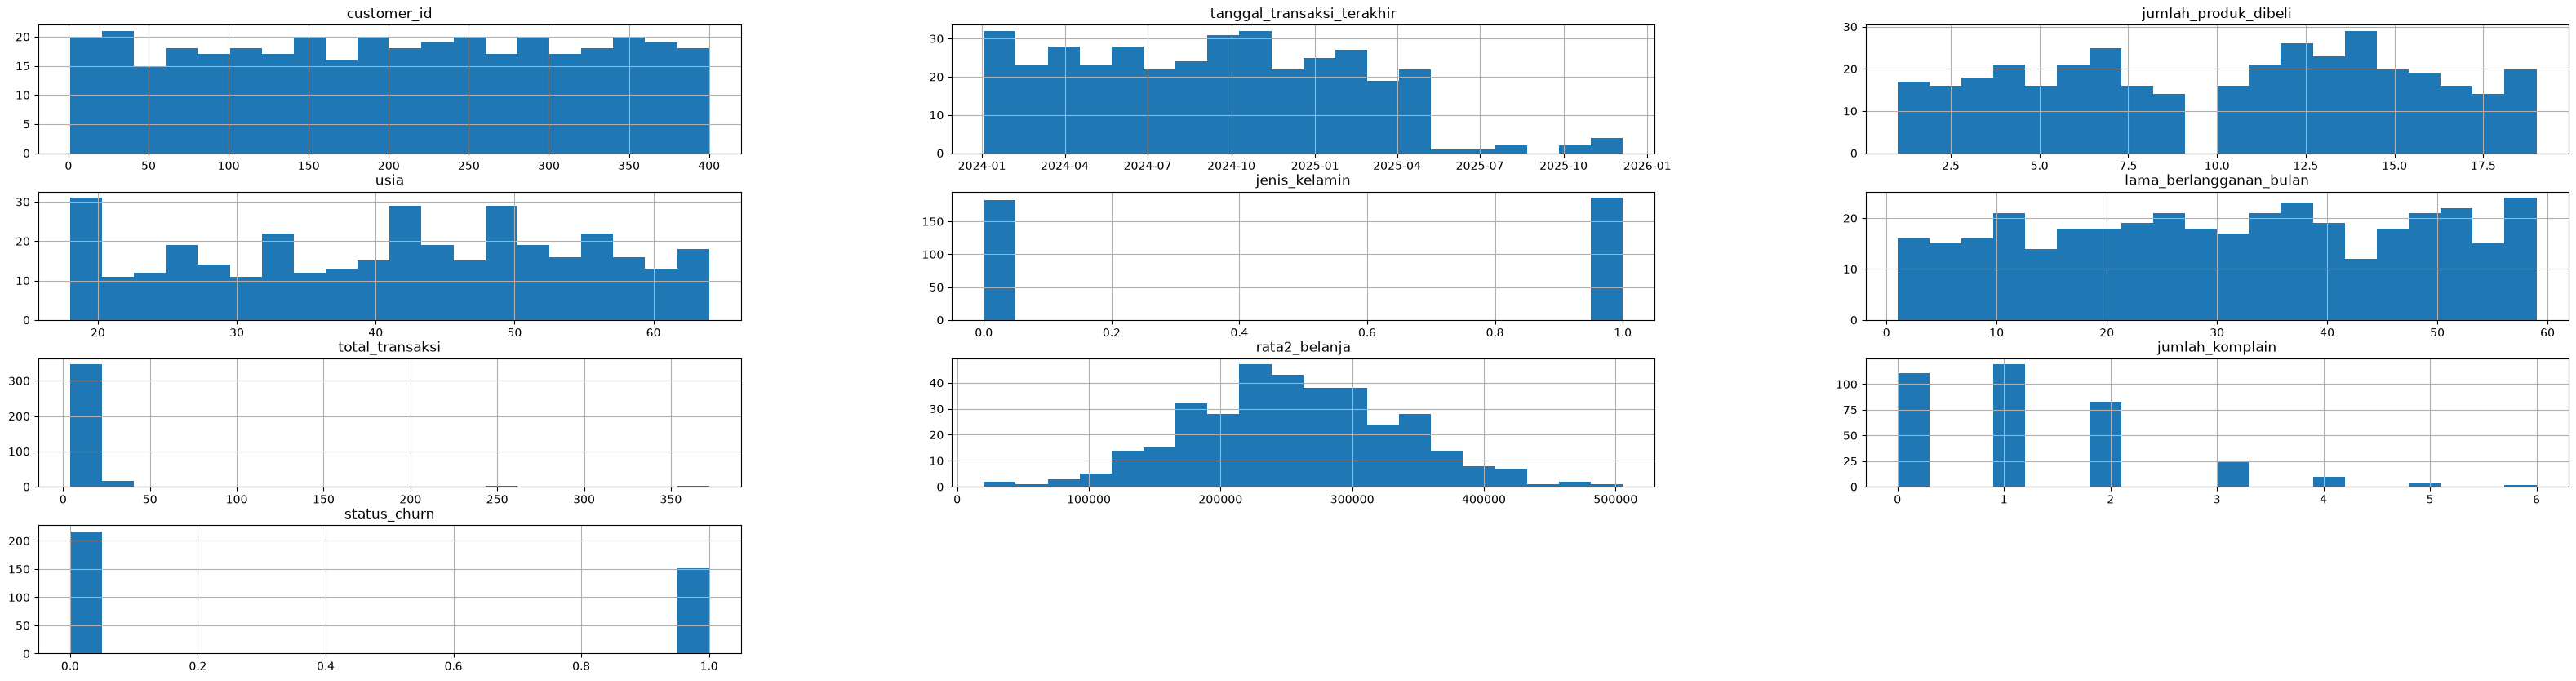

In [15]:
df_copy.hist(bins=20, figsize=(40, 10))
plt.show()

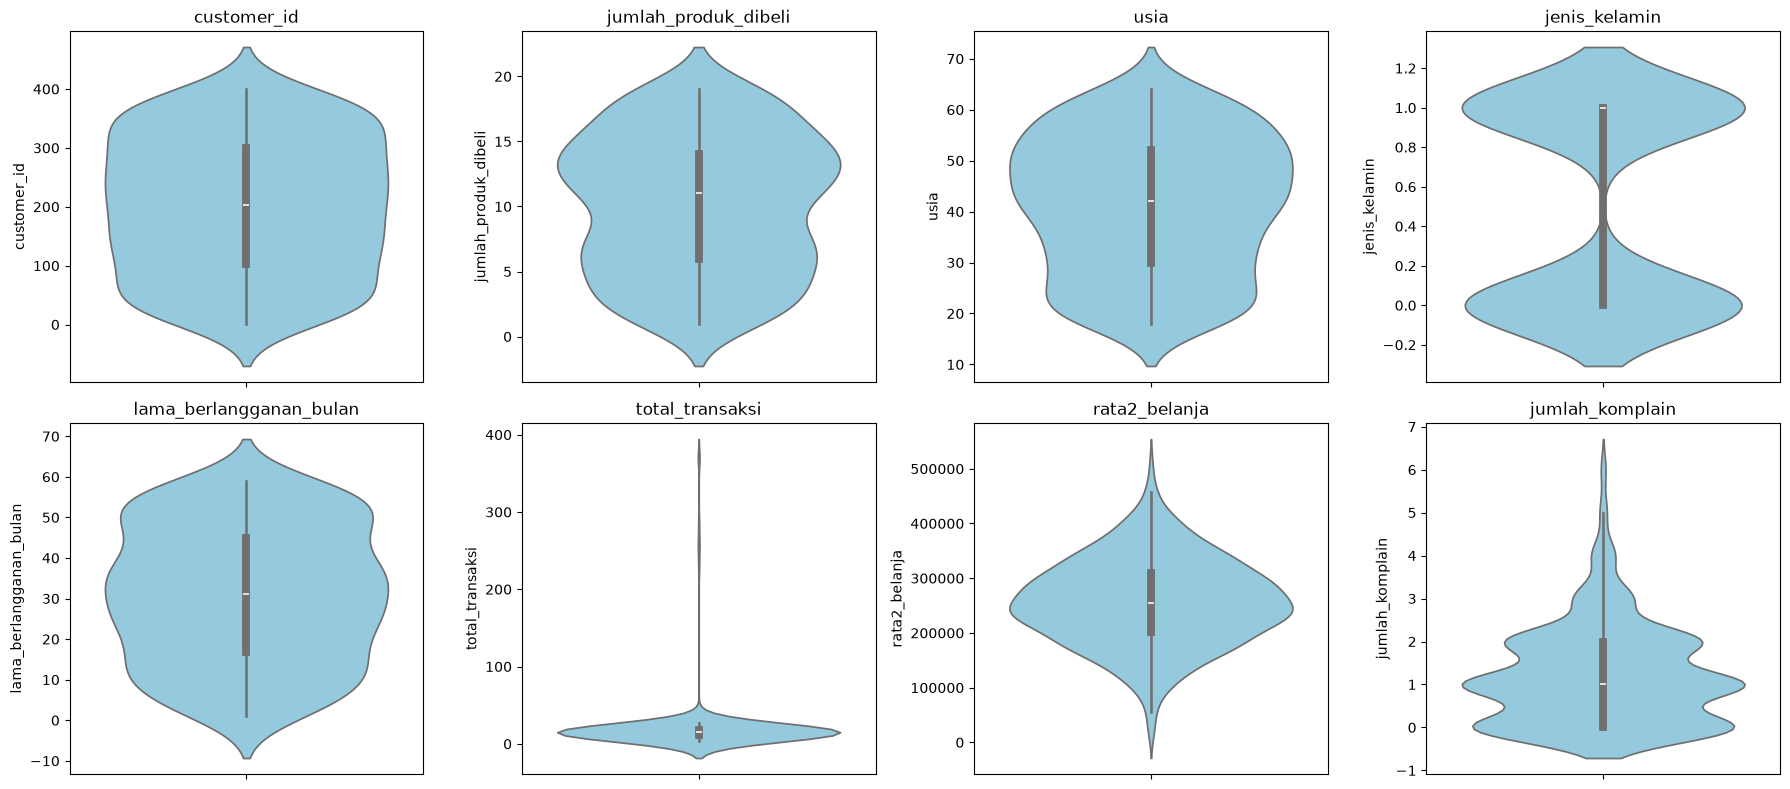

In [16]:
fitur = ['customer_id', 'jumlah_produk_dibeli', 'usia', 'jenis_kelamin',
         'lama_berlangganan_bulan', 'total_transaksi', 'rata2_belanja', 'jumlah_komplain']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, kolom in enumerate(fitur):
    sns.violinplot(y=df_copy[kolom], ax=axes[i], color='skyblue')
    axes[i].set_title(kolom)

plt.tight_layout()
plt.show()

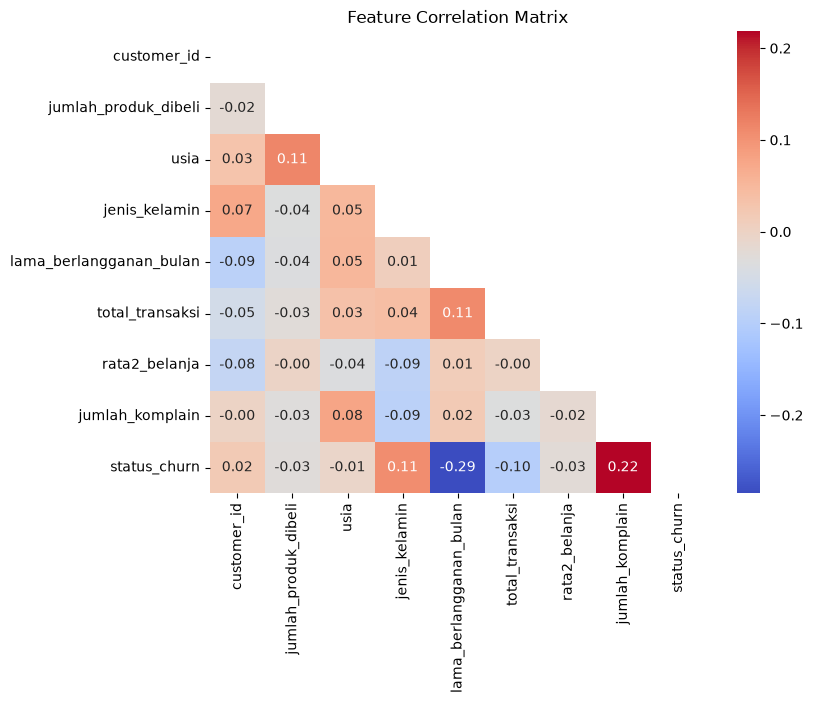

In [17]:
plt.figure(figsize=(8,6))
mask = np.triu(np.ones_like(df_copy.corr(numeric_only=True), dtype=bool))
sns.heatmap(df_copy.corr(numeric_only=True), annot=True, mask=mask, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

#### 2.3 Handling Missing Value ('usia', 'rata2_belanja', 'jumlah_komplain')

### 'usia'

In [18]:
df_copy['usia'] = df_copy['usia'].fillna(df_copy['usia'].median()) 

### 'rata2_belanja'

In [19]:
df_copy['rata2_belanja'] = df_copy['rata2_belanja'].fillna(df_copy['rata2_belanja'].median()) 

### 'jumlah_komplain'

In [20]:
df_copy['jumlah_komplain'] = df_copy['jumlah_komplain'].fillna(0) 

#### 2.4 Handling Duplicates

In [21]:
df_copy = df_copy.drop_duplicates()

In [22]:
df_copy.duplicated().sum()

np.int64(0)

#### Cek nilai kosong

In [23]:
df_copy.isnull().sum()

customer_id                   0
tanggal_transaksi_terakhir    0
jumlah_produk_dibeli          0
kategori_favorit              0
usia                          0
jenis_kelamin                 0
lama_berlangganan_bulan       0
total_transaksi               0
rata2_belanja                 0
jumlah_komplain               0
status_churn                  0
dtype: int64

Insight : Tidak ada lagi nilai kosong yang tersisa

#### 2.4 Encoding Category

In [24]:
df_copy = pd.get_dummies(df_copy, columns=['kategori_favorit'], dtype=int)
df_copy

,customer_id,tanggal_transaksi_terakhir,jumlah_produk_dibeli,usia,jenis_kelamin,lama_berlangganan_bulan,total_transaksi,rata2_belanja,jumlah_komplain,status_churn,kategori_favorit_Elektronik,kategori_favorit_Fashion,kategori_favorit_Kosmetik,kategori_favorit_Makanan,kategori_favorit_Rumah Tangga
0,104,2024-03-26,2,34.0,0,23.0,16.0,368202.0,2.0,1,0,0,1,0,0
1,215,2024-06-28,12,19.0,0,22.0,18.0,259062.0,1.0,0,1,0,0,0,0
2,111,2025-07-01,8,56.0,1,52.0,253.0,371076.0,0.0,0,0,0,0,0,1
3,177,2024-10-08,9,42.0,1,29.0,12.0,168734.0,0.0,1,1,0,0,0,0
4,316,2024-02-08,12,55.0,1,20.0,17.0,229236.0,1.0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
363,253,2024-11-20,8,18.0,1,39.0,20.0,169477.0,1.0,1,0,0,1,0,0
364,322,2024-09-08,17,51.0,0,3.0,18.0,254561.0,0.0,1,0,0,0,1,0
365,91,2024-10-10,18,46.0,0,52.0,10.0,414920.0,1.0,0,0,0,1,0,0
366,39,2024-04-05,12,24.0,0,30.0,11.0,281975.0,2.0,0,0,0,0,0,1


#### 2.5 Standard Scaler

In [25]:
df_copy.shape

(360, 15)

In [26]:
numeric_cols = ['usia', 'jumlah_produk_dibeli', 'lama_berlangganan_bulan', 
                'total_transaksi', 'rata2_belanja', 'jumlah_komplain']
scaler = StandardScaler()
df_copy[numeric_cols] = scaler.fit_transform(df_copy[numeric_cols])

#### 2.6 Handling Outlier

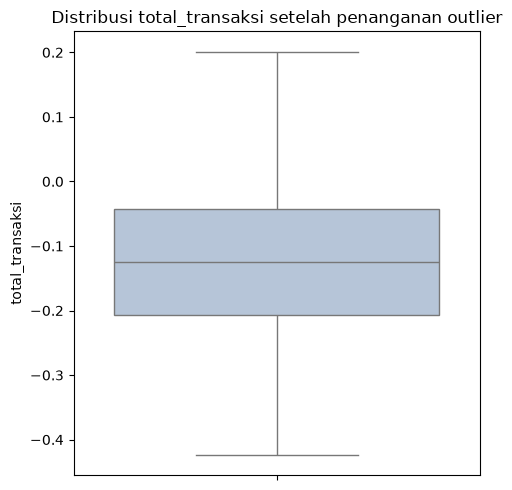

In [27]:
Q1 = df_copy['total_transaksi'].quantile(0.25)
Q3 = df_copy['total_transaksi'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

df_copy['total_transaksi'] = df_copy['total_transaksi'].clip(lower, upper)

fig, ax = plt.subplots(figsize=(5, 5))
sns.boxplot(data=df_copy['total_transaksi'], ax=ax, color='lightsteelblue')
ax.set_title('Distribusi total_transaksi setelah penanganan outlier')
plt.tight_layout()
plt.show()

## 3. DATA TRAINING & ALGORITHM TESTING

#### 3.1 Data Training

In [28]:
df_copy.head()

,customer_id,tanggal_transaksi_terakhir,jumlah_produk_dibeli,usia,jenis_kelamin,lama_berlangganan_bulan,total_transaksi,rata2_belanja,jumlah_komplain,status_churn,kategori_favorit_Elektronik,kategori_favorit_Fashion,kategori_favorit_Kosmetik,kategori_favorit_Makanan,kategori_favorit_Rumah Tangga
0,104,2024-03-26,-1.529252,-0.553825,0,-0.483089,-0.097622,1.444610,0.723196,1,0,0,1,0,0
1,215,2024-06-28,0.349692,-1.685792,0,-0.542812,-0.043262,0.031709,-0.144639,0,1,0,0,0,0
2,111,2025-07-01,-0.401885,1.106393,1,1.248866,0.201359,1.481817,-1.012474,0,0,0,0,0,1
3,177,2024-10-08,-0.213991,0.049890,1,-0.124754,-0.206342,-1.137657,-1.012474,1,1,0,0,0,0
4,316,2024-02-08,0.349692,1.030928,1,-0.662257,-0.070442,-0.354412,-0.144639,1,0,0,1,0,0


In [29]:
feature = ['customer_id', 'tanggal_transaksi_terakhir', 'jenis_kelamin', 'status_churn']

X = df_copy.drop(columns=feature)
y = df_copy['status_churn']

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train :", X_train.shape, " Test :", X_test.shape)
print("Churn Distribution Training :")
print(y_train.value_counts(normalize=True).round(3))

X_train : (288, 11)  Test : (72, 11)
Churn Distribution Training :
status_churn
0    0.594
1    0.406
Name: proportion, dtype: float64


#### 3.2 Algorithm Testing

In [30]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42, class_weight="balanced")
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)

rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

for name, pred in [('Decision Tree', pred_dt), ('Random Forest', pred_rf)]:
  print(f"--- {name} ---")
  print("Accuracy  :", round(accuracy_score(y_test, pred), 3))
  print("Precision  :", round(precision_score(y_test, pred, zero_division=0), 3))
  print("Recall  :", round(recall_score(y_test, pred, zero_division=0), 3))
  print("F1-Score  :", round(f1_score(y_test, pred, zero_division=0), 3))
  print()

--- Decision Tree ---
Accuracy  : 0.556
Precision  : 0.467
Recall  : 0.724
F1-Score  : 0.568

--- Random Forest ---
Accuracy  : 0.639
Precision  : 0.552
Recall  : 0.552
F1-Score  : 0.552



Insight : Kita sudah mendapatkan nilai dari masing-masing algoritma yang kita gunakan, karena data *churn* tidak seimbang (0: 0.594, 1: 406) Maka kita harus melakukan confusion matrix dengan Random Forest karena memiliki F1-Score tertinggi dibandingkan Decision Tree

#### 3.3 Confusion Matrix

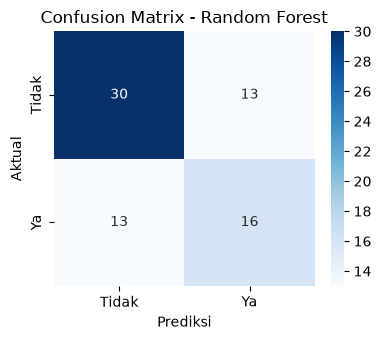

In [31]:
cm = confusion_matrix(y_test, pred_rf)
fig, ax = plt.subplots(figsize=(4,3.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak', 'Ya'], yticklabels=['Tidak', 'Ya'], ax=ax)
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

In [32]:
import joblib 

joblib.dump(rf, "tes_deploy.joblib")

['tes_deploy.joblib']